# K-Nearest Neighbours (KNN) Classification

## Objective
The objective of this assignment is to implement the K-Nearest Neighbours (KNN) algorithm for classification and evaluate its performance using different evaluation metrics.

The dataset is analyzed, preprocessed, and used to train a machine learning model that predicts the animal type based on the given features.

# Importing Required Libraries

In this step, all the required Python libraries for data analysis, visualization, preprocessing, and machine learning are imported.

- **Pandas** and **NumPy** are used for data manipulation.
- **Matplotlib** and **Seaborn** are used for data visualization.
- **Scikit-learn** is used for preprocessing, model building, and evaluation.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

# Loading the Dataset

The dataset is loaded into a Pandas DataFrame to perform analysis and preprocessing operations.

The initial rows of the dataset are displayed to understand the structure and contents of the data.

In [30]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.decomposition import PCA

df=pd.read_csv('zoo.csv')
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


# Dataset Information

The structure of the dataset is analyzed using:
- Number of rows and columns
- Data types of attributes
- Null values
- Memory usage

This helps in understanding the quality and format of the dataset before preprocessing.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [4]:
df.shape

(101, 18)

# Statistical Summary

The statistical summary provides important information such as:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This helps in identifying data distribution and possible outliers.

In [5]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


# Checking Missing Values

Missing values can affect model performance and accuracy.

In this step, the dataset is checked for null or missing values to ensure data quality before model training.

In [6]:
df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

# Checking Duplicate Records

Duplicate records may introduce bias into the model.

The dataset is checked for duplicate rows and removed if necessary.

In [35]:
df.duplicated().sum()

np.int64(0)

# Histogram Visualization

Histograms are used to visualize the distribution of numerical features in the dataset.

This helps in understanding:
- Feature spread
- Data distribution
- Skewness
- Frequency patterns

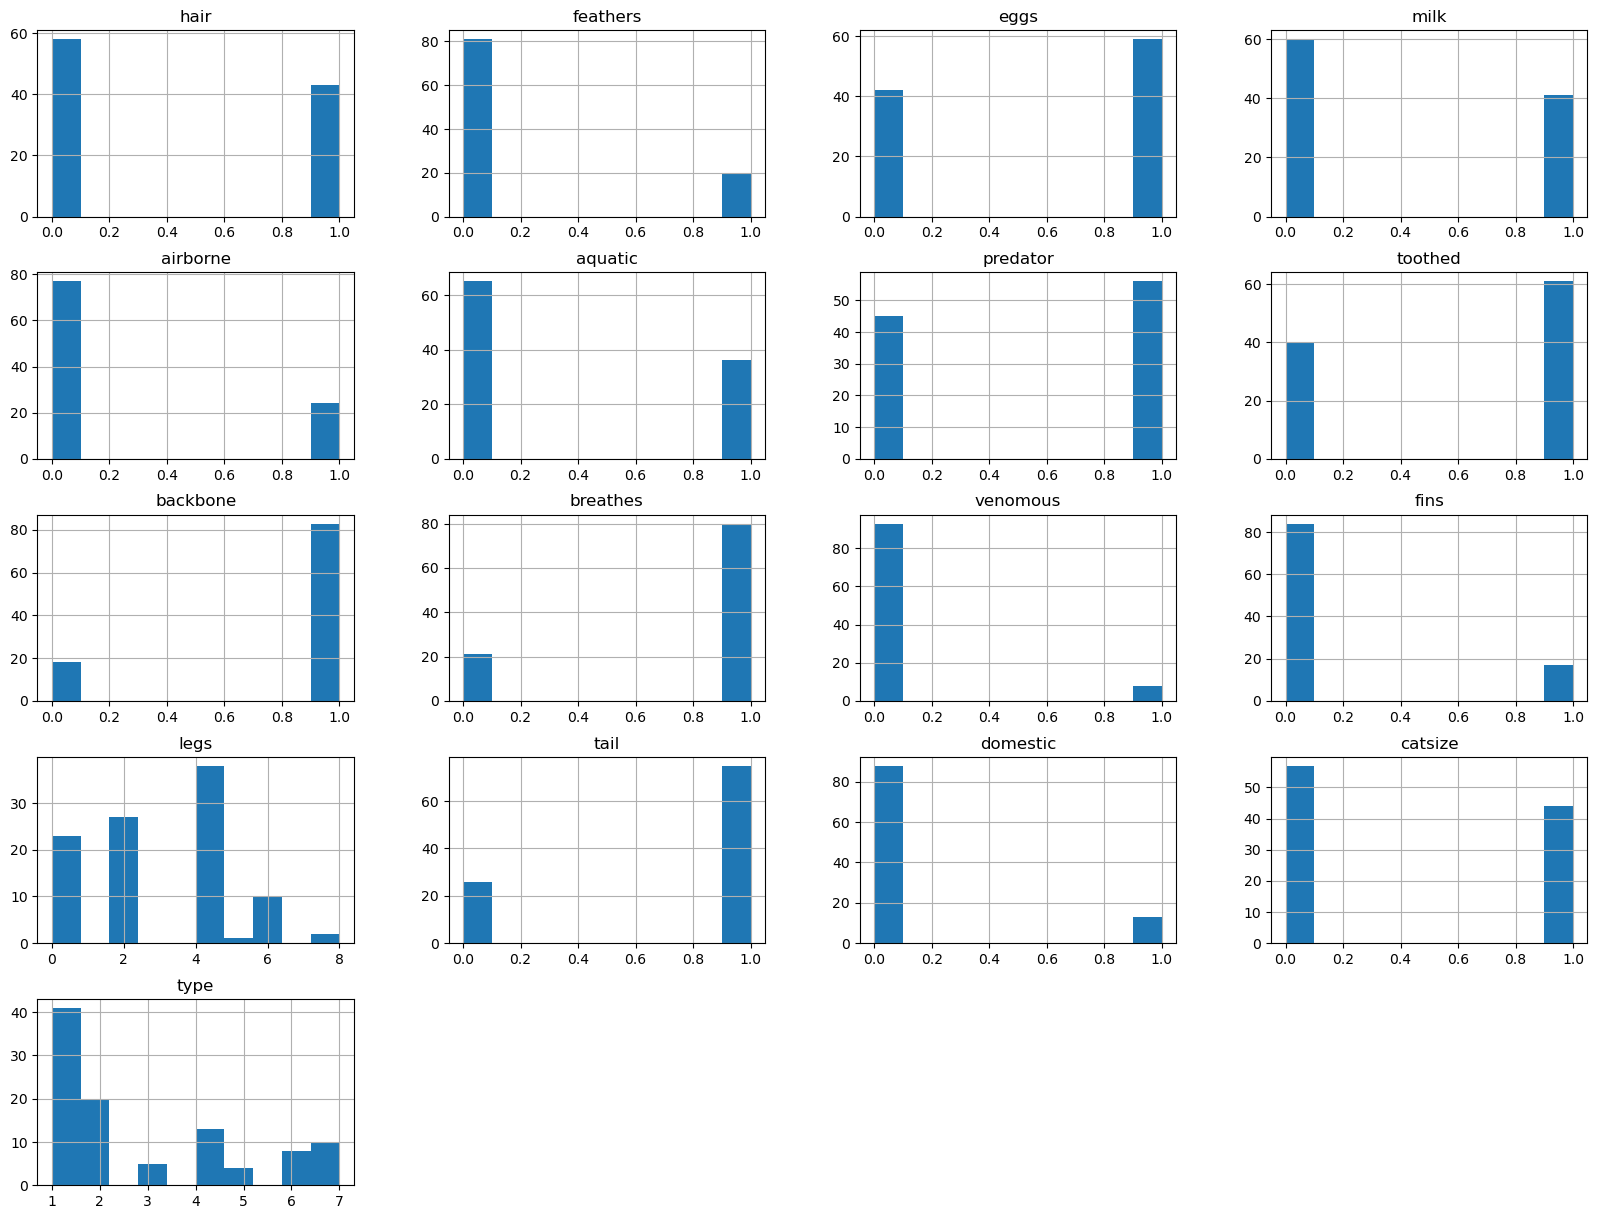

In [36]:
df.hist(figsize=(20,15))
plt.show()

In [9]:
df['type'].value_counts()

type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

In [10]:
df.columns

Index(['animal name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'type'],
      dtype='object')

In [11]:
df['animal name'].value_counts()

animal name
frog        2
aardvark    1
bass        1
antelope    1
bear        1
           ..
wallaby     1
wasp        1
wolf        1
worm        1
wren        1
Name: count, Length: 100, dtype: int64

# Outlier Detection using Boxplots

Boxplots are used to identify outliers in numerical features.

Outliers may affect distance-based algorithms like KNN because KNN relies on distance calculations.

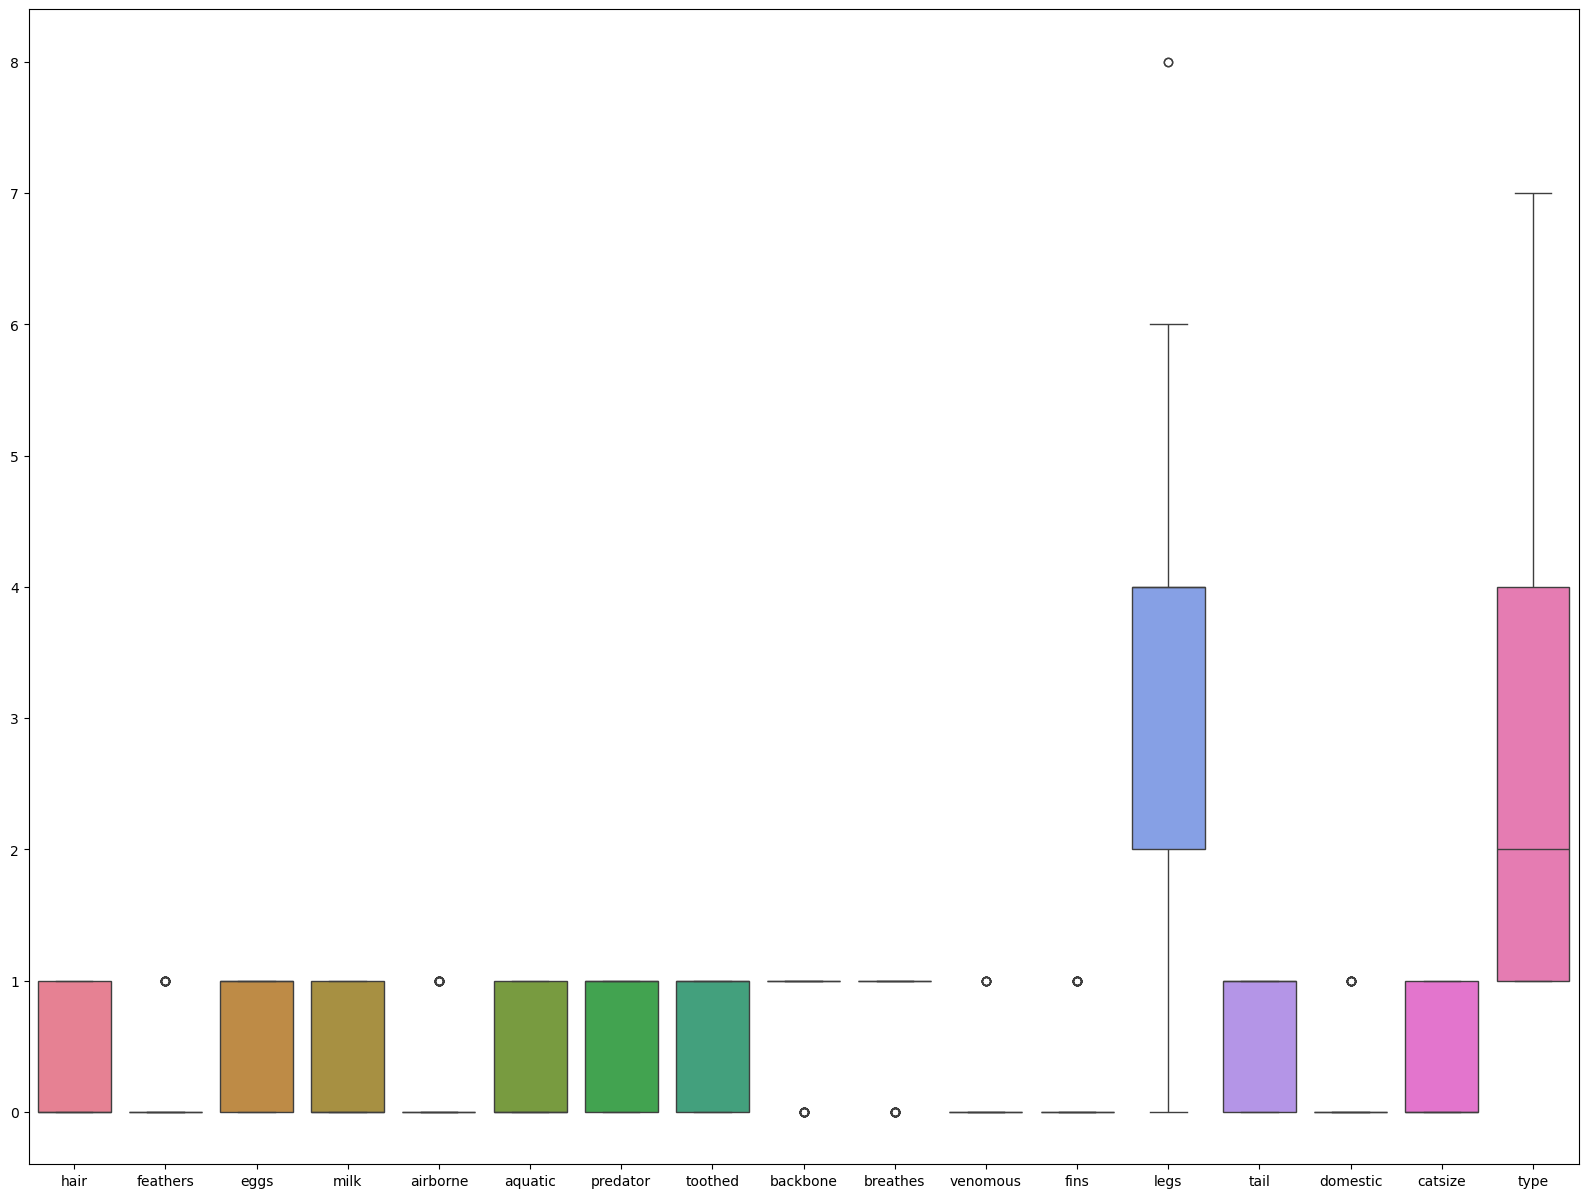

In [12]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.show()

# Label Encoding

Machine learning models require numerical input data.

Categorical values are converted into numerical form using Label Encoding so that the KNN algorithm can process the data efficiently.

In [13]:
le=LabelEncoder()
df['animal name']=le.fit_transform(df['animal name'])
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [14]:
df.skew()

animal name    0.019457
hair           0.304908
feathers       1.538501
eggs          -0.346676
milk           0.388876
airborne       1.251556
aquatic        0.608577
predator      -0.222443
toothed       -0.431569
backbone      -1.707118
breathes      -1.461244
venomous       3.163428
fins           1.799849
legs           0.139427
tail          -1.126430
domestic       2.250991
catsize        0.263515
type           0.852362
dtype: float64

# Outlier Detection using Boxplots

Boxplots are used to identify outliers in numerical features.

Outliers may affect distance-based algorithms like KNN because KNN relies on distance calculations.

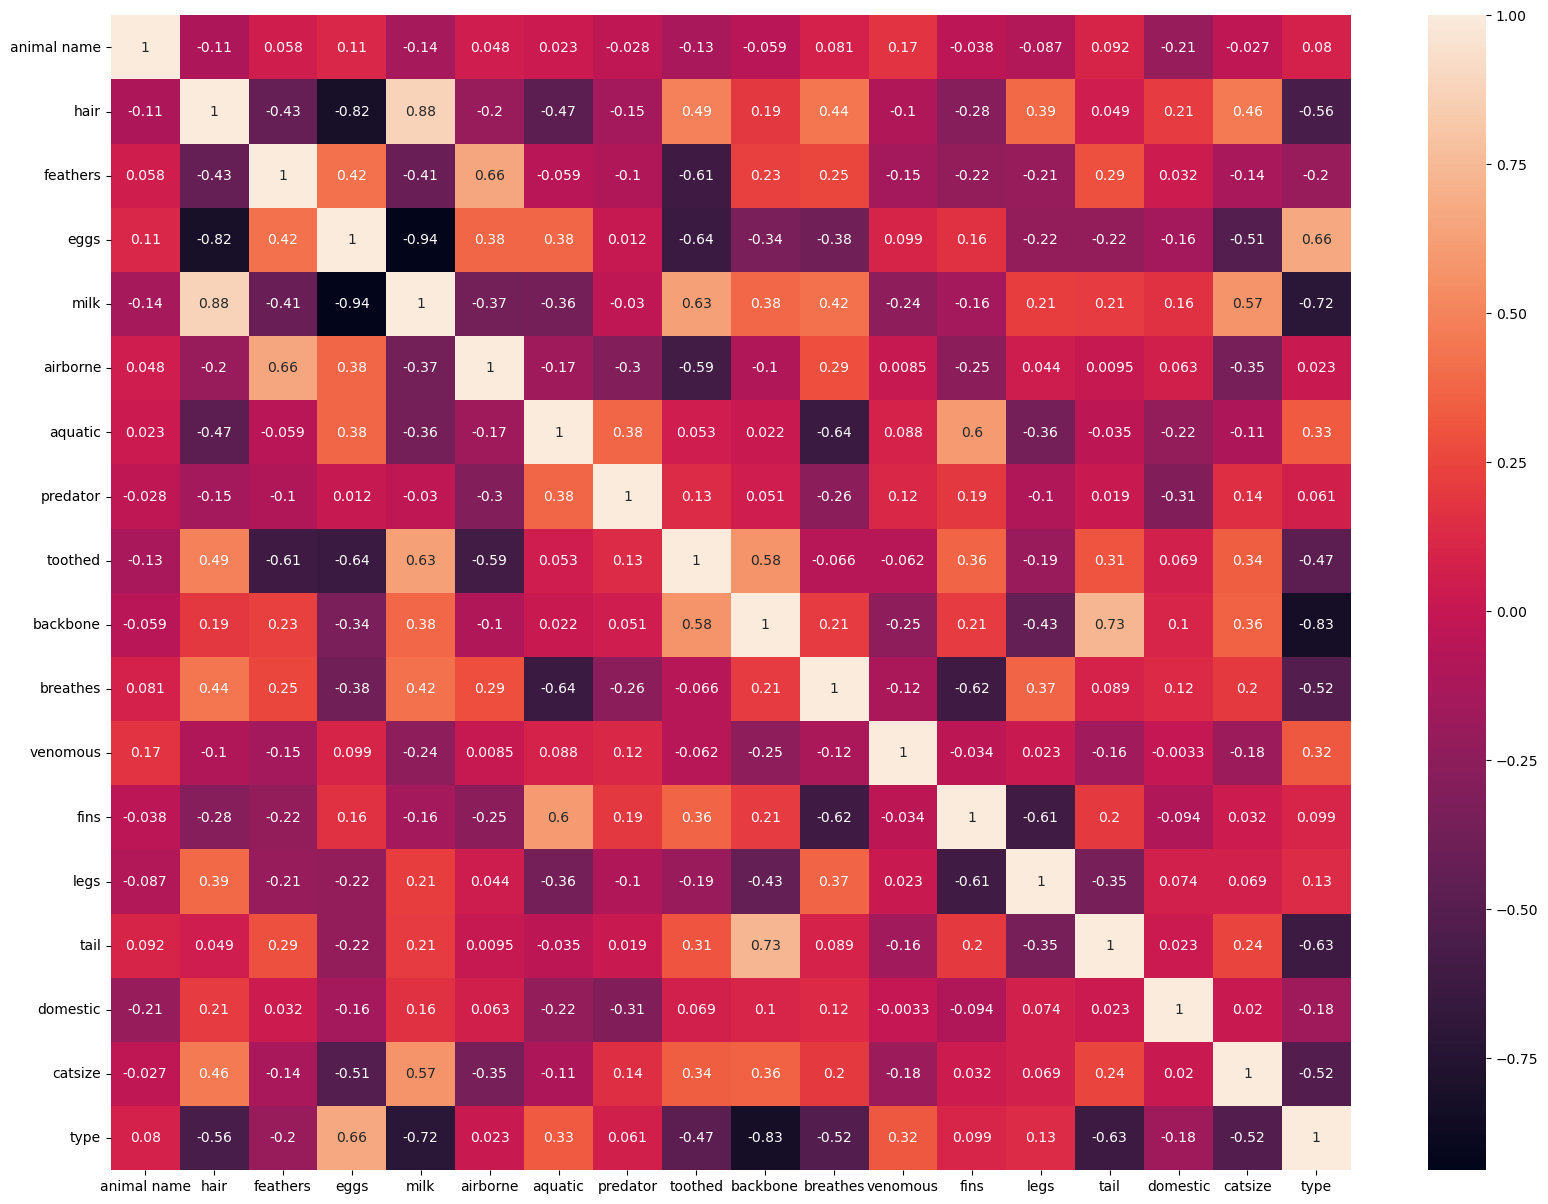

In [15]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

# Splitting Features and Target Variable

The dataset is divided into:
- Independent variables (Features)
- Dependent variable (Target)

The target variable contains the animal type to be predicted.
# Splitting the Dataset into Training and Testing Sets

The dataset is divided into:
- 80% Training Data
- 20% Testing Data

Training data is used to train the model, while testing data is used to evaluate model performance.

In [20]:
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(80, 17)
(21, 17)


# Feature Scaling

KNN is a distance-based algorithm, so feature scaling is very important.

Standardization is applied using StandardScaler to ensure all features are on the same scale and contribute equally to distance calculations.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Building the K-Nearest Neighbours Model

The KNN classifier is implemented using Scikit-learn.

The model classifies data points based on the majority class among the nearest neighboring data points.
# Training the Model

The KNN model is trained using the training dataset.

During training, the model learns patterns and relationships between the features and target classes.

In [22]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


# Model Prediction

The trained KNN model is used to predict the target values for the testing dataset.

The predicted values are compared with actual values to evaluate model performance.

In [23]:
y_pred = knn.predict(X_test_scaled)

print(y_pred)

[3 2 4 2 1 1 4 6 1 4 7 1 1 7 1 2 2 6 1 1 2]


# Accuracy Evaluation

Accuracy measures the percentage of correctly classified instances.

It is calculated as:

Accuracy = Correct Predictions / Total Predictions

Higher accuracy indicates better model performance.
# Classification Report

The classification report provides detailed evaluation metrics including:
- Precision
- Recall
- F1-Score
- Support

These metrics help evaluate the effectiveness of the classifier for each class.
# Confusion Matrix

The confusion matrix visualizes the classification performance of the model.

It shows:
- Correct predictions
- Incorrect predictions
- Class-wise performance

This helps in understanding where the model makes mistakes.

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9047619047619048

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       0.80      1.00      0.89         4
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           0.90        21
   macro avg       0.69      0.71      0.70        21
weighted avg       0.87      0.90      0.88        21


Confusion Matrix:

[[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]


# Confusion Matrix Heatmap

A heatmap representation of the confusion matrix is used to visualize the model's classification performance more clearly.

The heatmap helps identify:
- Correct classifications
- Misclassifications
- Class-wise prediction performance

Darker colors represent higher values in the confusion matrix.

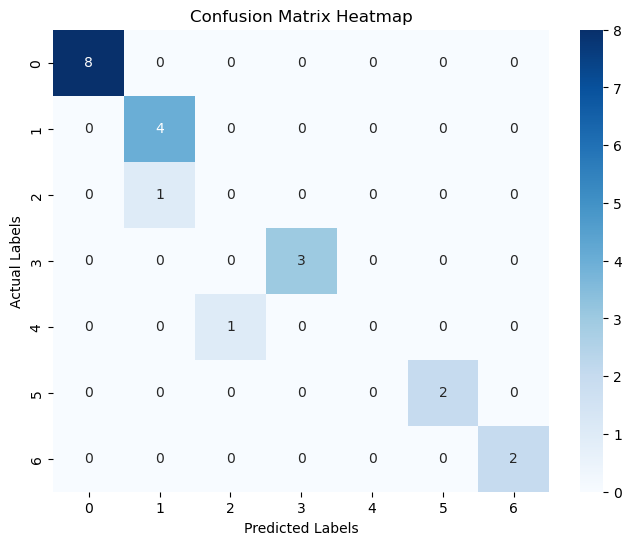

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.show()

# K Value Optimization Analysis

Different K values are tested to determine the optimal number of neighbors for the KNN classifier.

A smaller K value may lead to overfitting, while a larger K value may cause underfitting.

The optimal K value is selected based on the highest testing accuracy and balanced model performance.

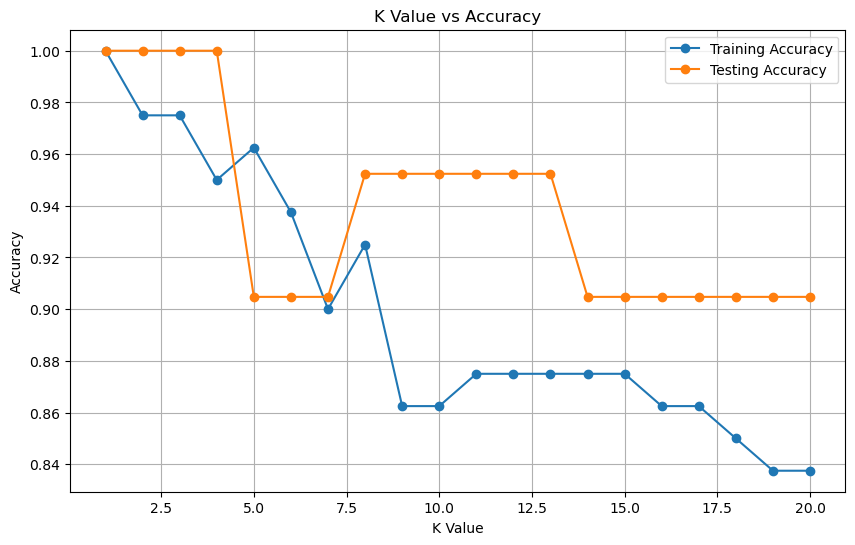

In [41]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

train_accuracy = []
test_accuracy = []

k_values = range(1, 21)

for k in k_values:
    
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    train_accuracy.append(
        model.score(X_train_scaled, y_train)
    )
    
    test_accuracy.append(
        model.score(X_test_scaled, y_test)
    )

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    train_accuracy,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    k_values,
    test_accuracy,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")
plt.legend()

plt.grid()

plt.show()

# Best K Value Selection

From the K Value vs Accuracy graph, the K value with the highest testing accuracy is selected as the optimal K value.

The selected K value provides a balance between:
- Bias
- Variance
- Model generalization

This improves the overall performance of the KNN classifier.

# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is used to reduce the dimensionality of the dataset into two principal components.

Reducing dimensions helps in:
- Simplifying visualization
- Improving interpretability
- Visualizing decision boundaries effectively

In [44]:
X_scaled=ss.fit_transform(x)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(101, 2)

In [45]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
knn_pca = KNeighborsClassifier(n_neighbors=5)

knn_pca.fit(X_train_pca, y_train_pca)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Decision Boundary Visualization

Decision boundaries show how the KNN classifier separates different classes within the feature space.

The visualization helps in understanding:
- Classification regions
- Neighbor influence
- Model decision patterns

PCA-reduced data is used to display the boundaries in two dimensions.

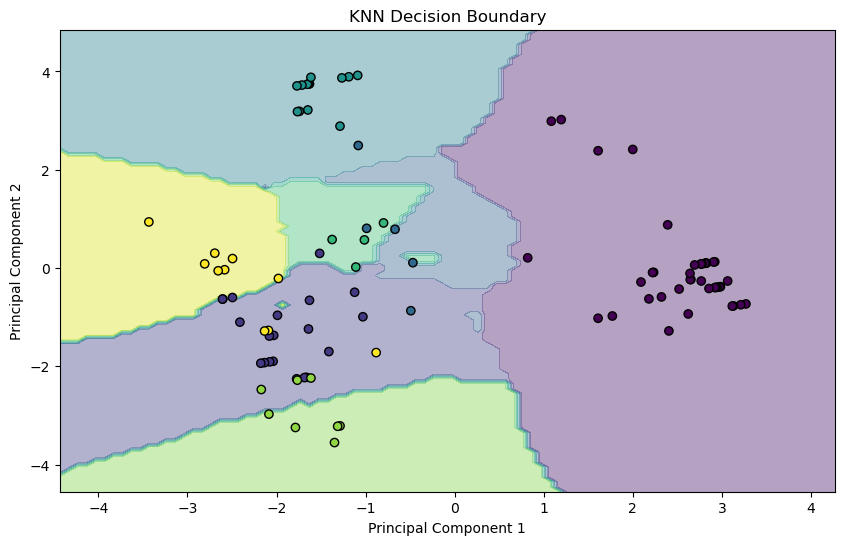

In [47]:
import numpy as np

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

Z = knn_pca.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    edgecolor='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("KNN Decision Boundary")

plt.show()

# Final Conclusion

In this assignment, the K-Nearest Neighbours (KNN) algorithm was successfully implemented for animal classification.

The dataset was analyzed using various visualization techniques and preprocessed through scaling and encoding methods. The model was trained and evaluated using multiple performance metrics including accuracy, precision, recall, and F1-score.

Different K values were tested to determine the optimal number of neighbors, and the model performance was analyzed using accuracy graphs and confusion matrix visualizations.

Principal Component Analysis (PCA) was applied to reduce dimensionality and visualize the decision boundaries of the classifier effectively.

The assignment demonstrated that KNN is a simple yet powerful distance-based machine learning algorithm capable of achieving effective classification performance on structured datasets.

## 1. What are the key hyperparameters in KNN?

The important hyperparameters in the K-Nearest Neighbours (KNN) algorithm are:

### 1. Number of Neighbors (K)
This determines how many nearest neighbors are considered during classification.

- Small K values may lead to overfitting.
- Large K values may lead to underfitting.

### 2. Distance Metric
The distance metric determines how similarity between data points is calculated.

Common distance metrics include:
- Euclidean Distance
- Manhattan Distance
- Minkowski Distance
- Hamming Distance

### 3. Weights
The weight parameter determines how neighbors contribute to prediction.

- **uniform** → All neighbors contribute equally.
- **distance** → Closer neighbors contribute more.

### 4. Algorithm
The algorithm parameter determines the searching technique used for nearest neighbors.

Examples:
- auto
- ball_tree
- kd_tree
- brute

### 5. Leaf Size
Leaf size affects the speed and memory usage of tree-based algorithms.

## 2. What distance metrics can be used in KNN?

KNN uses distance metrics to measure similarity between data points.

### 1. Euclidean Distance
The most commonly used distance metric.

It calculates the straight-line distance between two points.

Best suited for continuous numerical data.

### 2. Manhattan Distance
Calculates the sum of absolute differences between coordinates.

Useful when data contains high-dimensional features.

### 3. Minkowski Distance
A generalized form of both Euclidean and Manhattan distance.

It provides flexibility using different values of p.

### 4. Hamming Distance
Used for categorical or binary data.

It measures the number of differing positions between two values.

### 5. Cosine Similarity
Measures the angle between two vectors rather than physical distance.

Commonly used in text classification and recommendation systems.